In [2]:
pip install pandas matplotlib seaborn plotly streamlit

  Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached streamlit-1.56.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached narwhals-2.18.1-py3-none-any.whl.metadata (14 kB)
  Using cached altair-6.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd

# File path
file_path = r"C:\Users\hp\Desktop\project2\Sample - Superstore.csv"

# Load CSV with correct encoding
df = pd.read_csv(file_path, encoding='latin1')

# Show first 5 rows
print(df.head())

# Basic info (important for analysis)
print(df.info())

# Check missing values
print(df.isnull().sum())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [7]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert date columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Check again
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
# Total sales
print("Total Sales:", df['Sales'].sum())

# Total profit
print("Total Profit:", df['Profit'].sum())

# Top categories
print(df['Category'].value_counts())

Total Sales: 2297200.8603
Total Profit: 286397.0217
Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64


In [9]:
# Sales by category
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

# Profit by region
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print(region_profit)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


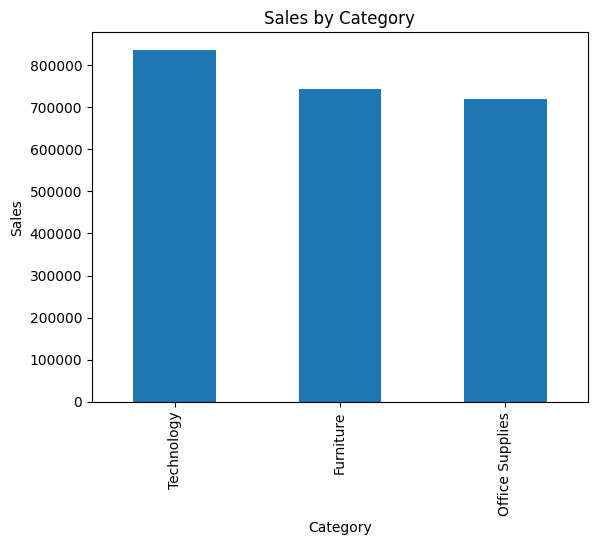

In [10]:
import matplotlib.pyplot as plt

# Sales by category chart
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

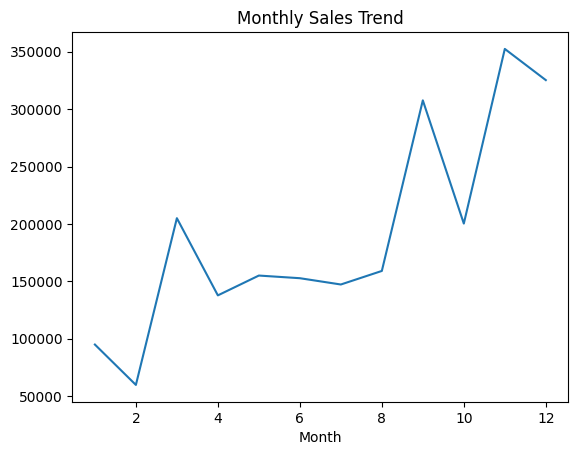

In [11]:
# Extract year and month
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

# Monthly sales
monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()

In [12]:
# Profit margin
df['Profit Margin'] = df['Profit'] / df['Sales']

# Worst performing sub-categories
worst = df.groupby('Sub-Category')['Profit Margin'].mean().sort_values()
print(worst.head(10))

Sub-Category
Binders       -0.199595
Appliances    -0.156869
Tables        -0.147727
Bookcases     -0.126640
Machines      -0.072026
Chairs         0.043900
Storage        0.089113
Supplies       0.112039
Phones         0.119222
Furnishings    0.137066
Name: Profit Margin, dtype: float64


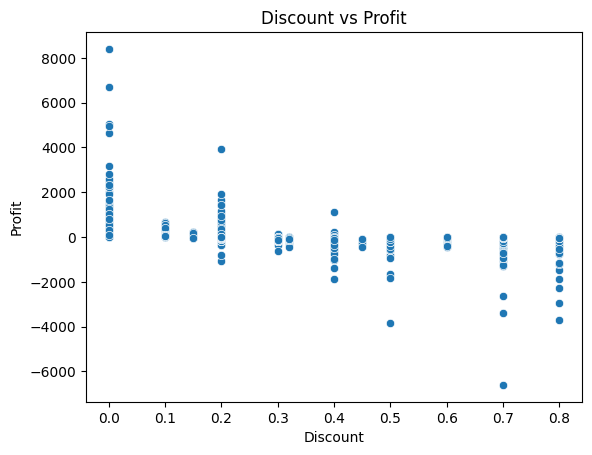

In [13]:
# Relation between discount and profit
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df['Discount'], y=df['Profit'])
plt.title("Discount vs Profit")
plt.show()

In [14]:
# Sales per customer
customer_sales = df.groupby('Customer Name')['Sales'].sum()

# Top customers
top_customers = customer_sales.sort_values(ascending=False).head(10)
print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


3.958174904942966


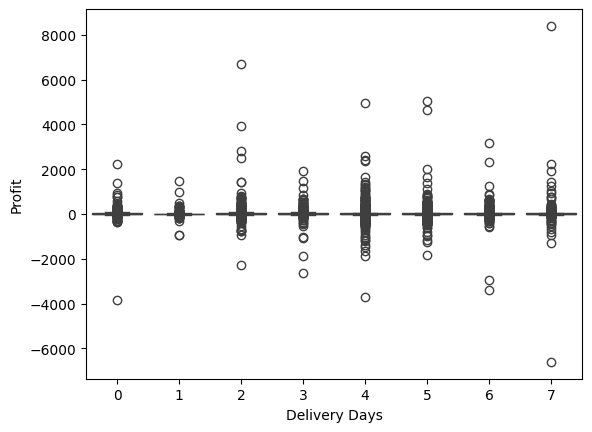

In [15]:
# Delivery time
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Average delivery time
print(df['Delivery Days'].mean())

# Delivery impact on profit
sns.boxplot(x=df['Delivery Days'], y=df['Profit'])
plt.show()

In [16]:
# Region + Category analysis
pivot = pd.pivot_table(df, 
                       values='Profit', 
                       index='Region', 
                       columns='Category', 
                       aggfunc='sum')

print(pivot)

Category   Furniture  Office Supplies  Technology
Region                                           
Central   -2871.0494        8879.9799  33697.4320
East       3046.1658       41014.5791  47462.0351
South      6771.2061       19986.3928  19991.8314
West      11504.9503       52609.8490  44303.6496


In [17]:
# Only loss-making orders
loss_df = df[df['Profit'] < 0]

# Top loss sub-categories
loss_analysis = loss_df.groupby('Sub-Category')['Profit'].sum().sort_values()
print(loss_analysis.head(10))

Sub-Category
Binders       -38510.4964
Tables        -32412.1483
Machines      -30118.6682
Bookcases     -12152.2060
Chairs         -9880.8413
Appliances     -8629.6412
Phones         -7530.6235
Furnishings    -6490.9134
Storage        -6426.3038
Supplies       -3015.6219
Name: Profit, dtype: float64


In [18]:
# Yearly growth
df['Year'] = df['Order Date'].dt.year

yearly_sales = df.groupby('Year')['Sales'].sum()
print(yearly_sales)

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64
